> **TÍTULO:** CyberSentinel-IoT: Detecção de Anomalias em dispositivos IoT com ML e sumarização por GenAI
>
> **DATASET:** [Bot-IoT](http://research.unsw.edu.au/projects/bot-iot-dataset) (Training-set / Testing-set - 10 best features)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    precision_recall_fscore_support, average_precision_score,
)
from xgboost import XGBClassifier

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

sns.set_theme(style="whitegrid")
SEED = 42

np.random.seed(42)

In [2]:
df_train = pd.read_csv("../data/Bot-IoT/UNSW_2018_IoT_Botnet_Final_10_best_Training.csv")
df_test  = pd.read_csv("../data/Bot-IoT/UNSW_2018_IoT_Botnet_Final_10_best_Testing.csv")

# Marcamos a origem de cada registro antes de combinar, para podermos separar novamente se necessário
df_train["origem"] = "train"
df_test["origem"]  = "test"

df_full = pd.concat([df_train, df_test], axis=0, ignore_index=True)

print(f"Treino : {df_train.shape[0]:,} linhas x {df_train.shape[1]} colunas".replace(",", "."))
print(f"Teste  : {df_test.shape[0]:,} linhas x {df_test.shape[1]} colunas".replace(",", "."))
print(f"Total  : {df_full.shape[0]:,} linhas x {df_full.shape[1]} colunas".replace(",", "."))

Treino : 2.934.817 linhas x 20 colunas
Teste  : 733.705 linhas x 20 colunas
Total  : 3.668.522 linhas x 20 colunas


In [3]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3668522 entries, 0 to 3668521
Data columns (total 20 columns):
 #   Column             Dtype  
---  ------             -----  
 0   pkSeqID            int64  
 1   proto              object 
 2   saddr              object 
 3   sport              object 
 4   daddr              object 
 5   dport              object 
 6   seq                int64  
 7   stddev             float64
 8   N_IN_Conn_P_SrcIP  int64  
 9   min                float64
 10  state_number       int64  
 11  mean               float64
 12  N_IN_Conn_P_DstIP  int64  
 13  drate              float64
 14  srate              float64
 15  max                float64
 16  attack             int64  
 17  category           object 
 18  subcategory        object 
 19  origem             object 
dtypes: float64(6), int64(6), object(8)
memory usage: 559.8+ MB


### _Features_ do dataset

| Nome da Feature | Tipo | Descrição |
| :--- | :--- | :--- |
| **pkSeqID** | `int64` | Identificador único da linha / registro |
| **proto** | `object` | Representação em texto do protocolo de transação no fluxo de rede |
| **saddr** | `object` | Endereço IP de origem (*Source IP*) |
| **sport** | `object` | Número da porta de origem (*Source port*) |
| **daddr** | `object` | Endereço IP de destino (*Destination IP*) |
| **dport** | `object` | Número da porta de destino (*Destination port*) |
| **seq** | `int64` | Número de sequência do Argus |
| **stddev** | `float64` | Desvio padrão da duração dos registros agregados |
| **N_IN_Conn_P_SrcIP** | `int64` | Número de conexões de entrada por IP de origem |
| **min** | `float64` | Duração mínima dos registros agregados |
| **state_number** | `int64` | Representação numérica do estado da transação (*state*) |
| **mean** | `float64` | Duração média dos registros agregados |
| **N_IN_Conn_P_DstIP** | `int64` | Número de conexões de entrada por IP de destino |
| **drate** | `float64` | Pacotes por segundo no sentido destino-para-origem |
| **srate** | `float64` | Pacotes por segundo no sentido origem-para-destino |
| **max** | `float64` | Duração máxima dos registros agregados |
| **attack** | `int64` | Rótulo da classe: `0` para tráfego Normal, `1` para Tráfego de Ataque |
| **category** | `object` | Categoria do tráfego de rede |
| **subcategory** | `object` | Subcategoria do tráfego de rede |
| **origem** | `object` | Metadado/Identificador da fonte/origem dos dados do registro |

In [4]:
# Separando os campos categóricos (`object`) e numéricos automaticamente, para conferência.
colunas_categoricas = df_full.select_dtypes(include="object").columns.tolist()
colunas_numericas   = df_full.select_dtypes(include=[np.number]).columns.tolist()

print(f"Campos categóricos ({len(colunas_categoricas)}):\n{colunas_categoricas}\n")
print(f"Campos numéricos ({len(colunas_numericas)}):\n{colunas_numericas}")

Campos categóricos (8):
['proto', 'saddr', 'sport', 'daddr', 'dport', 'category', 'subcategory', 'origem']

Campos numéricos (12):
['pkSeqID', 'seq', 'stddev', 'N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP', 'drate', 'srate', 'max', 'attack']


In [5]:
# df.sample() mostram exemplos reais de linhas, permitindo inspecionar visualmente o formato dos dados
df_full.sample(5, random_state=42)

,pkSeqID,proto,saddr,sport,daddr,dport,seq,stddev,N_IN_Conn_P_SrcIP,min,state_number,mean,N_IN_Conn_P_DstIP,drate,srate,max,attack,category,subcategory,origem
995784,3637643,udp,192.168.100.148,63063,192.168.100.5,28840,13988,0.000000,18,0.000000,4,0.000000,86,0.000000,0.000000,0.000000,1,Reconnaissance,Service_Scan,train
170580,613899,tcp,192.168.100.148,5071,192.168.100.6,80,88118,0.022247,23,0.000000,1,0.022042,23,0.017667,0.053008,0.048346,1,DoS,TCP,train
3141497,3633479,tcp,192.168.100.149,51456,192.168.100.5,8800,9790,0.000000,100,0.000918,1,0.000918,100,0.000000,0.000000,0.000918,1,Reconnaissance,Service_Scan,test
2925715,3667897,tcp,192.168.100.149,2166,192.168.100.5,1,8658,0.000000,25,0.000156,1,0.000156,100,0.000000,0.000000,0.000156,1,Reconnaissance,Service_Scan,train
3614039,2654500,udp,192.168.100.148,6724,192.168.100.3,80,25883,0.314900,100,3.481778,4,3.926956,100,0.000000,0.532142,4.159831,1,DDoS,UDP,test


In [6]:
# Amostra de valores únicos para cada campo categórico relevante:
for col in ["proto", "category", "subcategory"]:
    valores = df_full[col].unique()
    print(f"{col} ({df_full[col].nunique()} valores únicos): {sorted(map(str, valores))[:15]}"
          f"{' ...' if df_full[col].nunique() > 15 else ''}")

proto (5 valores únicos): ['arp', 'icmp', 'ipv6-icmp', 'tcp', 'udp']
category (5 valores únicos): ['DDoS', 'DoS', 'Normal', 'Reconnaissance', 'Theft']
subcategory (8 valores únicos): ['Data_Exfiltration', 'HTTP', 'Keylogging', 'Normal', 'OS_Fingerprint', 'Service_Scan', 'TCP', 'UDP']


In [7]:
resumo_numerico = df_full[colunas_numericas].describe().T
resumo_numerico["range"] = resumo_numerico["max"] - resumo_numerico["min"]
resumo_numerico[["min", "max", "mean", "std", "range"]].sort_values("range", ascending=False).head(15)

,min,max,mean,std,range
pkSeqID,1.0,3.668522e+06,1.834262e+06,1.059011e+06,3.668521e+06
srate,0.0,1.000000e+06,2.955111e+00,7.245425e+02,1.000000e+06
seq,1.0,2.622120e+05,1.213204e+05,7.579428e+04,2.622110e+05
drate,0.0,5.882353e+04,4.455046e-01,6.028863e+01,5.882353e+04
N_IN_Conn_P_DstIP,1.0,1.000000e+02,9.245168e+01,1.817643e+01,9.900000e+01
N_IN_Conn_P_SrcIP,1.0,1.000000e+02,8.253848e+01,2.439739e+01,9.900000e+01
state_number,1.0,1.100000e+01,3.134390e+00,1.186971e+00,1.000000e+01
max,0.0,4.999999e+00,3.020015e+00,1.860877e+00,4.999999e+00
mean,0.0,4.981882e+00,2.231063e+00,1.517728e+00,4.981882e+00
min,0.0,4.980471e+00,1.017540e+00,1.483688e+00,4.980471e+00


In [8]:
# Verificando balanceamento das classes (attack, category e subcategory)
print("Distribuição de 'attack' (0 = Normal, 1 = Ataque):")
print(df_full["attack"].value_counts())
print(f"Proporção de ataques: {df_full['attack'].mean():.2%}\n")

print("Distribuição de 'category':")
print(df_full["category"].value_counts())

print("\nDistribuição de 'subcategory':")
print(df_full["subcategory"].value_counts())

Distribuição de 'attack' (0 = Normal, 1 = Ataque):
attack
1    3668045
0        477
Name: count, dtype: int64
Proporção de ataques: 99.99%

Distribuição de 'category':
category
DDoS              1926624
DoS               1650260
Reconnaissance      91082
Normal                477
Theft                  79
Name: count, dtype: int64

Distribuição de 'subcategory':
subcategory
UDP                  1981230
TCP                  1593180
Service_Scan           73168
OS_Fingerprint         17914
HTTP                    2474
Normal                   477
Keylogging                73
Data_Exfiltration          6
Name: count, dtype: int64


In [9]:
# Removendo linhas duplicadas
qtd_duplicadas = df_full.duplicated().sum()
print(f"Linhas duplicadas encontradas: {qtd_duplicadas}")

if qtd_duplicadas > 0:
    df_full = df_full.drop_duplicates().reset_index(drop=True)
    print(f"Duplicadas removidas. Novo shape: {df_full.shape}")
else:
    print("Nenhuma duplicata encontrada.")

Linhas duplicadas encontradas: 0
Nenhuma duplicata encontrada.


### Padronização de campos categóricos

Removemos espaços em branco acidentais e uniformizamos a caixa (lowercase), prática comum para evitar que `'TCP'` e `'tcp '` sejam tratados como categorias diferentes.


In [10]:
for col in ["proto", "category", "subcategory"]:
    antes = df_full[col].nunique()
    df_full[col] = df_full[col].astype(str).str.strip().str.lower()
    depois = df_full[col].nunique()
    print(f"{col}: {antes} -> {depois} categorias únicas após strip() e lower()")

proto: 5 -> 5 categorias únicas após strip() e lower()
category: 5 -> 5 categorias únicas após strip() e lower()
subcategory: 8 -> 8 categorias únicas após strip() e lower()


### Verificação de valores ausentes (nulos)


In [11]:
nulos_por_coluna = df_full.isnull().sum()
total_nulos = nulos_por_coluna.sum()

print(f"Total de valores nulos no dataset: {total_nulos}")
if total_nulos > 0:
    print(nulos_por_coluna[nulos_por_coluna > 0])
else:
    print("Nenhum valor nulo (NaN) real no dataset original.")

Total de valores nulos no dataset: 0
Nenhum valor nulo (NaN) real no dataset original.


### Filtro 1: Somente tráfego malicioso (`label == 1`)

Isola todos os registros classificados como ataque, independentemente da categoria: separa o que é "estranho" do que é tráfego normal.


In [12]:
df_ataques = df_full[df_full["attack"] == 1]

print(f"Registros de ataque: {len(df_ataques):,} de {len(df_full):,} ({len(df_ataques)/len(df_full):.2%})".replace(",", "."))
df_ataques.head(3)

Registros de ataque: 3.668.045 de 3.668.522 (99.99%)


,pkSeqID,proto,saddr,sport,daddr,dport,seq,stddev,N_IN_Conn_P_SrcIP,min,state_number,mean,N_IN_Conn_P_DstIP,drate,srate,max,attack,category,subcategory,origem
0,3142762,udp,192.168.100.150,6551,192.168.100.3,80,251984,1.900363,100,0.00000,4,2.687519,100,0.0,0.494549,4.031619,1,ddos,udp,train
1,2432264,tcp,192.168.100.150,5532,192.168.100.3,80,256724,0.078003,38,3.85693,3,3.934927,100,0.0,0.256493,4.012924,1,ddos,tcp,train
2,1976315,tcp,192.168.100.147,27165,192.168.100.3,80,62921,0.268666,100,2.97410,3,3.341429,100,0.0,0.294880,3.609205,1,ddos,tcp,train


### Filtro 2: Somente tráfego normal (`label == 0`)

Filtro usado como baseline de comparação (ex.: para treinar o modelo de detecção de anomalia apenas com tráfego legítimo, técnica comum em Isolation Forest/Autoencoders).


In [13]:
df_normal = df_full[df_full["attack"] == 0]

print(f"Registros normais: {len(df_normal):,} de {len(df_full):,} ({len(df_normal)/len(df_full):.2%})".replace(",", "."))

Registros normais: 477 de 3.668.522 (0.01%)


### Filtro 3: Uma família específica de ataque (`category == 'ddos'`)

Isola apenas os registros da categoria "ddos", permitindo estudar o comportamento característico desse tipo de ataque (ex.: alto volume de pacotes em curto intervalo de tempo).


In [14]:
df_ddos = df_full[df_full["category"].str.lower() == "ddos"]

print(f"Registros da categoria DDoS: {len(df_ddos):,}".replace(",", "."))
df_ddos.describe()


Registros da categoria DDoS: 1.926.624


,pkSeqID,seq,stddev,N_IN_Conn_P_SrcIP,min,state_number,mean,N_IN_Conn_P_DstIP,drate,srate,max,attack
count,1.926624e+06,1.926624e+06,1.926624e+06,1.926624e+06,1.926624e+06,1.926624e+06,1.926624e+06,1.926624e+06,1.926624e+06,1.926624e+06,1.926624e+06,1926624.0
mean,2.613572e+06,1.232739e+05,9.453554e-01,8.195921e+01,1.301874e+00,3.043381e+00,2.549634e+00,9.990743e+01,7.041794e-03,5.153571e-01,3.348972e+00,1.0
std,5.561686e+05,7.378819e+04,7.517980e-01,2.420960e+01,1.491054e+00,1.191124e+00,1.404212e+00,2.195074e+00,3.566600e-02,6.061590e-01,1.646568e+00,0.0
min,1.650261e+06,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.0
25%,2.131917e+06,6.009200e+04,1.230160e-01,6.800000e+01,0.000000e+00,3.000000e+00,2.016244e+00,1.000000e+02,0.000000e+00,2.498630e-01,3.262079e+00,1.0
50%,2.613572e+06,1.202990e+05,9.376220e-01,9.700000e+01,1.696500e-01,3.000000e+00,2.759816e+00,1.000000e+02,0.000000e+00,4.100830e-01,4.057637e+00,1.0
75%,3.095228e+06,1.831780e+05,1.690094e+00,1.000000e+02,2.763413e+00,4.000000e+00,3.659881e+00,1.000000e+02,0.000000e+00,6.346650e-01,4.172465e+00,1.0
max,3.576884e+06,2.621680e+05,2.496763e+00,1.000000e+02,4.980471e+00,7.000000e+00,4.981882e+00,1.000000e+02,1.064578e+00,7.339449e+00,4.999999e+00,1.0


### Filtro 4: Subtipo específico (`subcategory == 'tcp'`)

Filtra apenas as categorias que usam o protocolo TCP.

In [15]:
df_tcp = df_full[df_full["subcategory"] == "tcp"]

print(f"Conexões TCP: {len(df_tcp):,} de {len(df_full):,} ({len(df_tcp)/len(df_full):.2%})".replace(",", "."))

Conexões TCP: 1.593.180 de 3.668.522 (43.43%)


---
## Limpeza e preparação dos dados para treinamento

Objetivo: deixar no dataset apenas **características de comportamento do tráfego**. Identificadores, IPs e portas fazem o modelo "decorar" o testbed do Bot-IoT (quem ataca quem, em qual porta) em vez de aprender o que é um ataque, o que é incompatível com a meta de um IDS generalista para dispositivos IoT diferentes.

### 1.1 Remoção de identificadores, IPs, portas e metadados

| Coluna | Motivo da remoção |
| :--- | :--- |
| `pkSeqID`, `seq` | Identificadores de linha / sequência do Argus: refletem a ordem de captura, não o comportamento do tráfego |
| `saddr`, `daddr` | IPs do testbed: o modelo aprenderia "esse IP é o atacante" |
| `sport`, `dport` | Portas: específicas do cenário de captura (e vêm como texto misto) |
| `origem` | Metadado criado por nós (`train` / `test`) |

In [16]:
colunas_para_remover = ["pkSeqID", "saddr", "daddr", "sport", "dport", "seq", "origem"]
df_clean = df_full.drop(columns=colunas_para_remover)

print(f"Shape após remoção: {df_clean.shape[0]:,} linhas x {df_clean.shape[1]} colunas".replace(",", "."))
print(f"Colunas restantes: {df_clean.columns.tolist()}")

Shape após remoção: 3.668.522 linhas x 13 colunas
Colunas restantes: ['proto', 'stddev', 'N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP', 'drate', 'srate', 'max', 'attack', 'category', 'subcategory']


### 1.2 Duplicatas após remover os identificadores

A checagem de duplicatas feita no início rodou *com* `pkSeqID` e `seq`, que tornam toda linha única. Sem eles, fluxos idênticos aparecem como duplicatas exatas. Se ficassem, cópias da mesma linha cairiam em treino e teste ao mesmo tempo (**vazamento de dados**) e inflariam as métricas.

In [17]:
antes = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Duplicatas exatas removidas: {antes - len(df_clean):,} ({(antes - len(df_clean)) / antes:.2%})".replace(",", "."))

# Linhas com features idênticas, mas rótulos diferentes (ruído de rótulo, ambíguas para qualquer modelo).
# Como as duplicatas exatas já saíram, qualquer repetição de features restante tem rótulo distinto.
colunas_features = [c for c in df_clean.columns if c not in ["attack", "category", "subcategory"]]
n_conflitos = df_clean.duplicated(subset=colunas_features, keep=False).sum()
print(f"Linhas com features idênticas e rótulos conflitantes: {n_conflitos:,}".replace(",", "."))

print("\nDistribuição por (category, subcategory) após deduplicação:")
print(df_clean.groupby(["category", "subcategory"]).size().sort_values(ascending=False))

Duplicatas exatas removidas: 2.014.991 (54.93%)
Linhas com features idênticas e rótulos conflitantes: 5.754

Distribuição por (category, subcategory) após deduplicação:
category        subcategory      
ddos            tcp                  478939
dos             udp                  476654
ddos            udp                  427247
dos             tcp                  239480
reconnaissance  service_scan          20943
                os_fingerprint         7296
dos             http                   1485
ddos            http                    989
normal          normal                  423
theft           keylogging               69
                data_exfiltration         6
dtype: int64


### 1.3 Encoding da variável categórica `proto` (One-Hot)

`proto` é a única categórica de rede que sobrou. `category` e `subcategory` são **rótulos** (o que queremos prever), portanto jamais entram como variáveis de entrada. Mantemo-las apenas para estratificação, amostragem e avaliação.

Também criamos a coluna auxiliar `classe` (`categoria_subcategoria`, ex.: `ddos_udp`), usada para balancear e estratificar com granularidade fina.

In [18]:
print("Valores de 'proto':", df_clean["proto"].unique().tolist())

df_clean = pd.get_dummies(df_clean, columns=["proto"], prefix="proto", dtype=int)

# Rótulo combinado (granularidade fina): tráfego normal vira apenas "normal"
df_clean["classe"] = np.where(df_clean["attack"] == 0, "normal",
                              df_clean["category"] + "_" + df_clean["subcategory"])

COLUNAS_ROTULO = ["attack", "category", "subcategory", "classe"]
FEATURES = [c for c in df_clean.columns if c not in COLUNAS_ROTULO]

print(f"\nFeatures de entrada do modelo ({len(FEATURES)}):\n{FEATURES}")
df_clean.head()

Valores de 'proto': ['udp', 'tcp', 'icmp', 'arp', 'ipv6-icmp']

Features de entrada do modelo (14):
['stddev', 'N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP', 'drate', 'srate', 'max', 'proto_arp', 'proto_icmp', 'proto_ipv6-icmp', 'proto_tcp', 'proto_udp']


,stddev,N_IN_Conn_P_SrcIP,min,state_number,mean,N_IN_Conn_P_DstIP,drate,srate,max,attack,category,subcategory,proto_arp,proto_icmp,proto_ipv6-icmp,proto_tcp,proto_udp,classe
0,1.900363,100,0.000000,4,2.687519,100,0.0,0.494549,4.031619,1,ddos,udp,0,0,0,0,1,ddos_udp
1,0.078003,38,3.856930,3,3.934927,100,0.0,0.256493,4.012924,1,ddos,tcp,0,0,0,1,0,ddos_tcp
2,0.268666,100,2.974100,3,3.341429,100,0.0,0.294880,3.609205,1,ddos,tcp,0,0,0,1,0,ddos_tcp
3,1.823185,63,0.000000,4,3.222832,63,0.0,0.461435,4.942302,1,dos,udp,0,0,0,0,1,dos_udp
4,0.822418,100,2.979995,4,3.983222,100,0.0,1.002999,4.994452,1,ddos,udp,0,0,0,0,1,ddos_udp


---
## Estatística visual e relação entre variáveis

### 2.1 Matriz de correlação

Inclui a coluna `attack` para evidenciar quais features mais se relacionam com o rótulo. A correlação é calculada sobre o dataset completo (limpo), antes do balanceamento, por isso reflete principalmente o comportamento dos ataques, que são 99,99% das linhas.

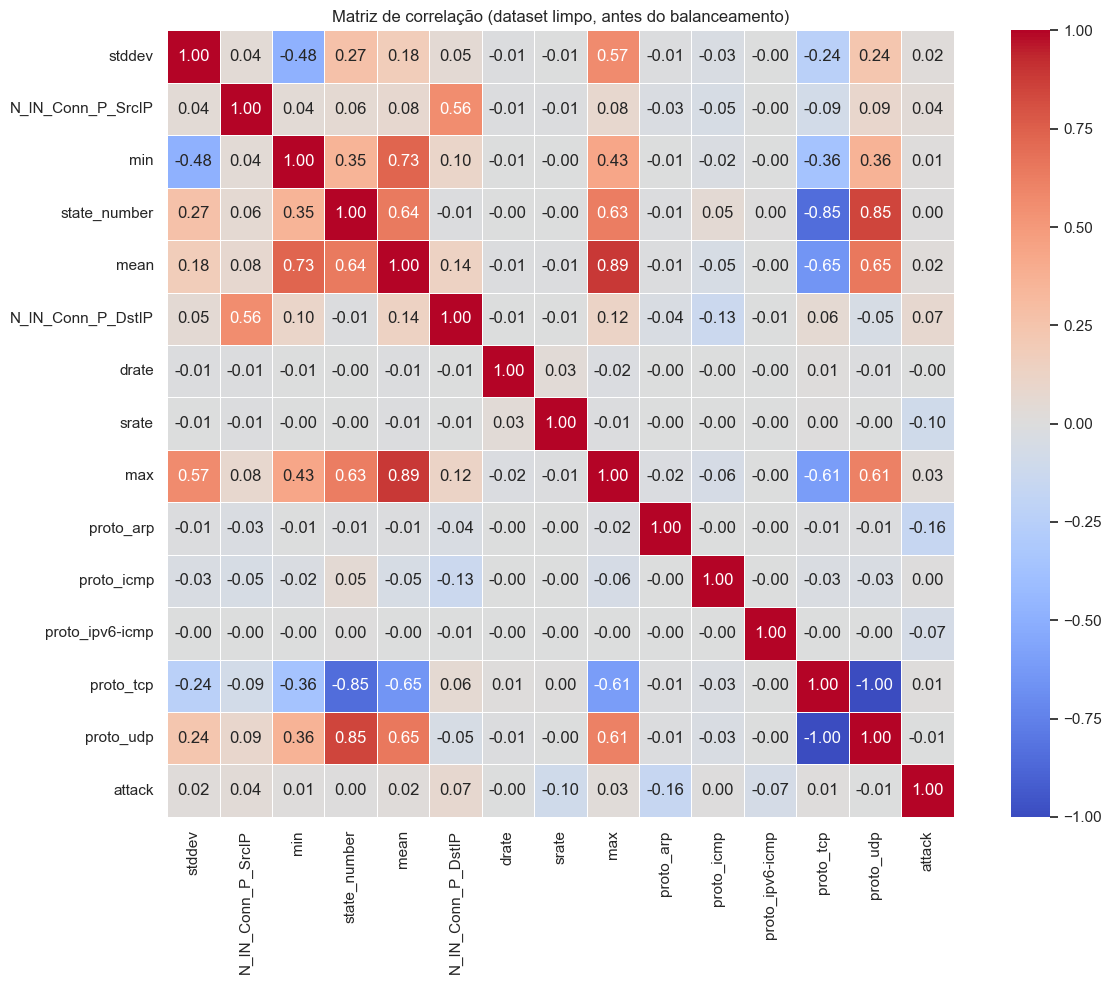

Features mais correlacionadas com 'attack' (em módulo):
proto_arp           -0.156
srate               -0.100
N_IN_Conn_P_DstIP    0.074
proto_ipv6-icmp     -0.069
N_IN_Conn_P_SrcIP    0.039
max                  0.025
mean                 0.021
stddev               0.017
Name: attack, dtype: float64


In [19]:
corr = df_clean[FEATURES + ["attack"]].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Matriz de correlação (dataset limpo, antes do balanceamento)")
plt.tight_layout()
plt.show()

print("Features mais correlacionadas com 'attack' (em módulo):")
print(corr["attack"].drop("attack").sort_values(key=np.abs, ascending=False).head(8).round(3))

### 2.2 Boxplots: `attack == 0` vs `attack == 1`

Para não plotar 3,6 milhões de linhas, usamos **todos** os registros normais e uma amostra aleatória de 50 mil ataques, só para visualização. `srate` e `drate` têm cauda extremamente longa (até 10⁶), então usam escala *symlog* no eixo Y.

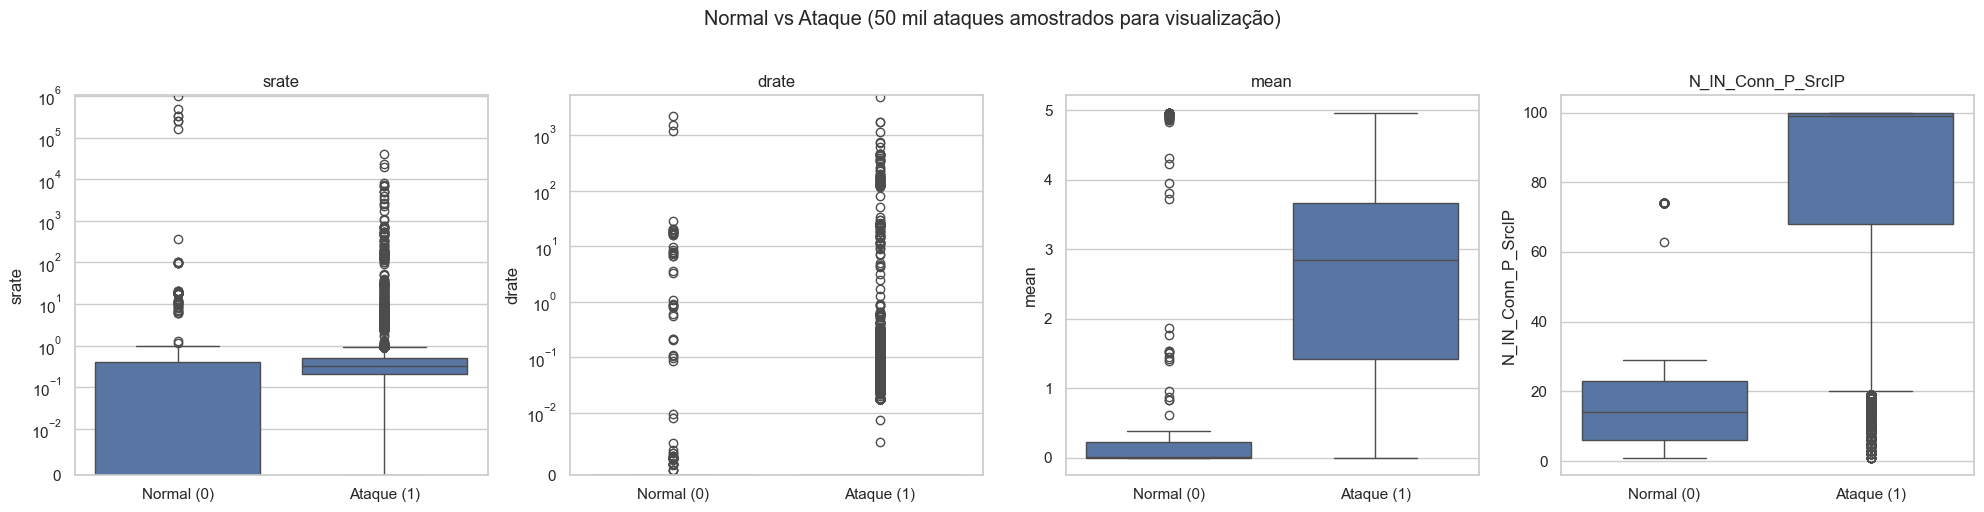

Mediana por classe:
             srate  drate    mean  N_IN_Conn_P_SrcIP
tipo                                                
Ataque (1)  0.3144    0.0  2.8502               99.0
Normal (0)  0.0000    0.0  0.0100               14.0


In [20]:
normais_plot = df_clean[df_clean["attack"] == 0]
ataques_plot = df_clean[df_clean["attack"] == 1].sample(n=min(50_000, (df_clean["attack"] == 1).sum()), random_state=SEED)
df_plot = pd.concat([normais_plot, ataques_plot])
df_plot["tipo"] = df_plot["attack"].map({0: "Normal (0)", 1: "Ataque (1)"})

cols_box = ["srate", "drate", "mean", "N_IN_Conn_P_SrcIP"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col in zip(axes, cols_box):
    sns.boxplot(data=df_plot, x="tipo", y=col, order=["Normal (0)", "Ataque (1)"], ax=ax)
    if col in ("srate", "drate"):
        ax.set_yscale("symlog", linthresh=1e-2)
        ax.set_ylim(bottom=0)      # taxas nunca são negativas
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Normal vs Ataque (50 mil ataques amostrados para visualização)", y=1.02)
plt.tight_layout()
plt.show()

print("Mediana por classe:")
print(df_plot.groupby("tipo")[cols_box].median().round(4))

---
## Tratando o desbalanceamento extremo (undersampling)

São apenas 477 registros normais contra ~3,6 milhões de ataques. A estratégia:

1. Manter **todos** os registros normais.
2. Para cada tipo de ataque (grupo `category` + `subcategory`, ex.: DDoS-UDP, DDoS-TCP, DoS-UDP, Reconnaissance-Service_Scan...), sortear **no máximo** `LIMITE_POR_GRUPO` amostras. Grupos menores que o limite (ex.: `Theft`) são mantidos inteiros.

> **Atenção:** o undersampling muda a prevalência real (ataques deixam de ser 99,99%). Precision e Recall medidos depois valem para essa mistura balanceada artificialmente, não para o tráfego real de uma rede.

In [21]:
LIMITE_POR_GRUPO = 5_000
chaves_ataque = ["category", "subcategory"]

normais = df_clean[df_clean["attack"] == 0]
ataques = df_clean[df_clean["attack"] == 1]

# Embaralha e pega as primeiras N linhas de cada grupo (amostragem aleatória; grupos pequenos ficam inteiros)
ataques_amostra = ataques.sample(frac=1, random_state=SEED).groupby(chaves_ataque).head(LIMITE_POR_GRUPO)

df_bal = pd.concat([normais, ataques_amostra]).sample(frac=1, random_state=SEED).reset_index(drop=True)

comparativo = pd.DataFrame({
    "antes":  df_clean["classe"].value_counts(),
    "depois": df_bal["classe"].value_counts(),
}).sort_values("antes", ascending=False)
display(comparativo)

print(f"\nDataset balanceado: {len(df_bal):,} linhas (de {len(df_clean):,})".replace(",", "."))
print(f"Proporção de normais: {(df_bal['attack'] == 0).mean():.2%} | ataques: {df_bal['attack'].mean():.2%}")

,antes,depois
classe,,
ddos_tcp,478939,5000
dos_udp,476654,5000
ddos_udp,427247,5000
dos_tcp,239480,5000
reconnaissance_service_scan,20943,5000
reconnaissance_os_fingerprint,7296,5000
dos_http,1485,1485
ddos_http,989,989
normal,423,423



Dataset balanceado: 32.972 linhas (de 1.653.531)
Proporção de normais: 1.28% | ataques: 98.72%


---
## Modelagem e avaliação

### 4.1 Separação em treino e teste (estratificada)

Uma única divisão 80/20, estratificada pelo rótulo fino (`classe`), garante que até as classes minúsculas (`theft_*`) apareçam em treino e teste. Essa mesma divisão serve para as duas tarefas:

* **Binária:** `attack` (0 = normal, 1 = ataque)
* **Multiclasse:** `category` (normal, ddos, dos, reconnaissance, theft). Mude `ALVO_MULTICLASSE` para `"classe"` se quiser o nível de subcategoria (atenção: `data_exfiltration` tem só 6 registros no dataset inteiro, então suas métricas serão ruidosas).

In [22]:
ALVO_MULTICLASSE = "category"      # ou "classe" para granularidade fina

X       = df_bal[FEATURES]
y_bin   = df_bal["attack"]
y_multi = df_bal[ALVO_MULTICLASSE]

X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X, y_bin, y_multi,
    test_size=0.2, stratify=df_bal["classe"], random_state=SEED,
)

print(f"Treino: {X_train.shape[0]:,} linhas | Teste: {X_test.shape[0]:,} linhas".replace(",", "."))
print(f"\nNormais no treino: {(y_train_bin == 0).sum()} | no teste: {(y_test_bin == 0).sum()}")
print("\nDistribuição do alvo multiclasse (treino / teste):")
print(pd.DataFrame({"treino": y_train_multi.value_counts(), "teste": y_test_multi.value_counts()}))

Treino: 26.377 linhas | Teste: 6.595 linhas

Normais no treino: 338 | no teste: 85

Distribuição do alvo multiclasse (treino / teste):
                treino  teste
category                     
dos               9188   2297
ddos              8791   2198
reconnaissance    8000   2000
normal             338     85
theft               60     15


### 4.2 Funções de avaliação

Como o dataset segue desbalanceado (~1,5% normais), **a acurácia é ignorada**. Usamos Precision, Recall, F1 e matriz de confusão. Convenções:

* **Binário:** a classe positiva é o **ataque**. *Recall (ataque)* é a taxa de detecção; *Recall (normal)* indica o quanto de tráfego legítimo passa sem gerar falso alarme. Também reportamos a **PR-AUC**, que independe de limiar.
* **Multiclasse:** médias *macro* (cada classe pesa igual, então `theft` conta tanto quanto `ddos`), mais o desempenho na classe `normal`.

In [23]:
res_bin, res_multi = [], []   # acumulam os resultados para a tabela final


def avaliar_binario(nome, y_true, y_pred, score=None):
    print("=" * 64, f"\n{nome}\n" + "=" * 64)
    print(classification_report(y_true, y_pred, labels=[0, 1],
                                target_names=["Normal", "Ataque"], digits=4, zero_division=0))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, labels=[0, 1],
                                            display_labels=["Normal", "Ataque"],
                                            cmap="Blues", colorbar=False, values_format="d")
    plt.title(nome)
    plt.show()

    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    res_bin.append({
        "Modelo": nome,
        "Precision (ataque)": p[1], "Recall (ataque)": r[1], "F1 (ataque)": f[1],
        "Recall (normal)": r[0], "F1 macro": f.mean(),
        "PR-AUC (ataque)": average_precision_score(y_true, score) if score is not None else np.nan,
    })


def avaliar_multiclasse(nome, y_true, y_pred):
    labels = sorted(pd.Series(y_true).unique())
    print("=" * 64, f"\n{nome}\n" + "=" * 64)
    print(classification_report(y_true, y_pred, labels=labels, digits=4, zero_division=0))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, labels=labels, cmap="Blues",
                                            colorbar=False, xticks_rotation=45, values_format="d")
    plt.title(nome)
    plt.show()

    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)
    i_normal = labels.index("normal")
    res_multi.append({
        "Modelo": nome,
        "Precision macro": p.mean(), "Recall macro": r.mean(), "F1 macro": f.mean(),
        "Recall (normal)": r[i_normal], "F1 (normal)": f[i_normal],
    })

### 4.3 Random Forest (baseline supervisionado)

`class_weight="balanced"` compensa os ~1,5% de normais restantes, penalizando mais os erros nas classes raras.

Random Forest (binário)
              precision    recall  f1-score   support

      Normal     0.9884    1.0000    0.9942        85
      Ataque     1.0000    0.9998    0.9999      6510

    accuracy                         0.9998      6595
   macro avg     0.9942    0.9999    0.9970      6595
weighted avg     0.9999    0.9998    0.9998      6595



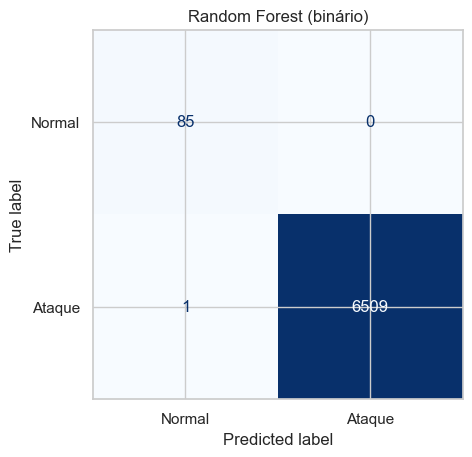

In [24]:
# --- Binário ---
rf_bin = RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1, random_state=SEED)
rf_bin.fit(X_train, y_train_bin)
avaliar_binario("Random Forest (binário)", y_test_bin,
                rf_bin.predict(X_test), rf_bin.predict_proba(X_test)[:, 1])

Random Forest (multiclasse)
                precision    recall  f1-score   support

          ddos     0.9950    0.9895    0.9922      2198
           dos     0.9892    0.9956    0.9924      2297
        normal     0.9882    0.9882    0.9882        85
reconnaissance     0.9980    0.9970    0.9975      2000
         theft     1.0000    0.9333    0.9655        15

      accuracy                         0.9938      6595
     macro avg     0.9941    0.9808    0.9872      6595
  weighted avg     0.9938    0.9938    0.9938      6595



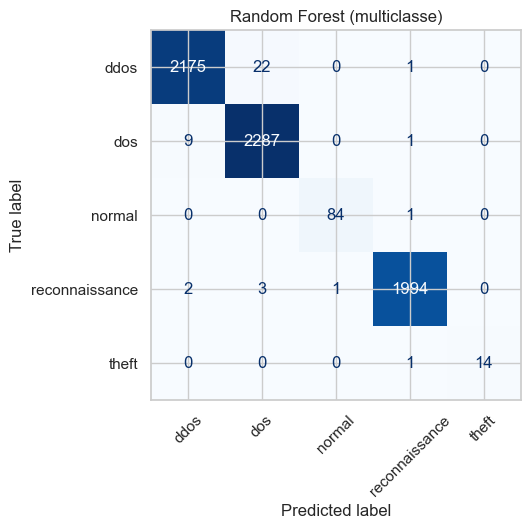

In [25]:
# --- Multiclasse ---
rf_multi = RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1, random_state=SEED)
rf_multi.fit(X_train, y_train_multi)
avaliar_multiclasse("Random Forest (multiclasse)", y_test_multi, rf_multi.predict(X_test))

### 4.4 XGBoost (baseline supervisionado)

No caso binário, `scale_pos_weight = n_normais / n_ataques` equaliza o peso total das duas classes (por isso o valor é < 1: a classe positiva, ataque, é a majoritária). No multiclasse, o mesmo efeito vem de `sample_weight` balanceado.

XGBoost (binário)
              precision    recall  f1-score   support

      Normal     0.7727    1.0000    0.8718        85
      Ataque     1.0000    0.9962    0.9981      6510

    accuracy                         0.9962      6595
   macro avg     0.8864    0.9981    0.9349      6595
weighted avg     0.9971    0.9962    0.9964      6595



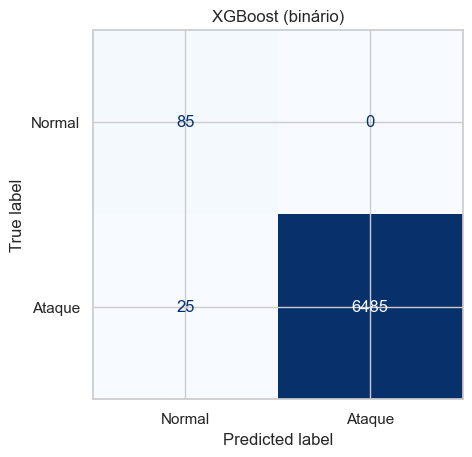

In [26]:
# --- Binário ---
spw = (y_train_bin == 0).sum() / (y_train_bin == 1).sum()
xgb_bin = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, scale_pos_weight=spw,
                        tree_method="hist", eval_metric="logloss", n_jobs=-1, random_state=SEED)
xgb_bin.fit(X_train, y_train_bin)
avaliar_binario("XGBoost (binário)", y_test_bin,
                xgb_bin.predict(X_test), xgb_bin.predict_proba(X_test)[:, 1])

XGBoost (multiclasse)
                precision    recall  f1-score   support

          ddos     0.9982    0.9914    0.9948      2198
           dos     0.9918    0.9983    0.9950      2297
        normal     0.9765    0.9765    0.9765        85
reconnaissance     0.9975    0.9980    0.9978      2000
         theft     1.0000    0.9333    0.9655        15

      accuracy                         0.9955      6595
     macro avg     0.9928    0.9795    0.9859      6595
  weighted avg     0.9955    0.9955    0.9954      6595



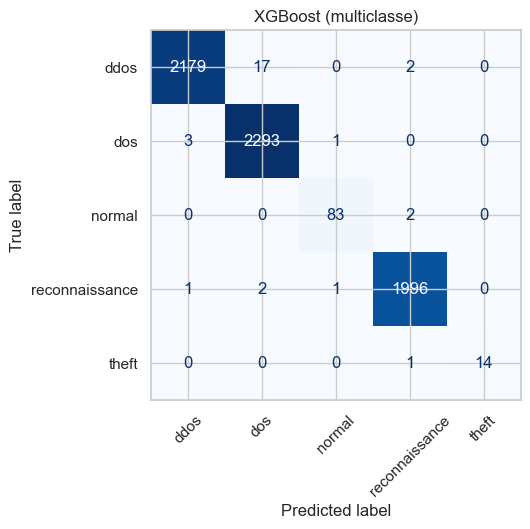

In [27]:
# --- Multiclasse (XGBoost exige alvo numérico) ---
le = LabelEncoder().fit(y_train_multi)
y_train_enc = le.transform(y_train_multi)

xgb_multi = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                          tree_method="hist", eval_metric="mlogloss", n_jobs=-1, random_state=SEED)
xgb_multi.fit(X_train, y_train_enc, sample_weight=compute_sample_weight("balanced", y_train_enc))

y_pred_xgb_multi = le.inverse_transform(xgb_multi.predict(X_test))
avaliar_multiclasse("XGBoost (multiclasse)", y_test_multi, y_pred_xgb_multi)

### 4.5 Isolation Forest (detecção de anomalias, treinada **só com tráfego normal**)

O modelo nunca vê um ataque no treino: aprende o "normal" e marca como anomalia o que destoa. É a abordagem mais próxima de um IDS que precisa reconhecer ataques *inéditos*.

O limiar de decisão é definido **apenas com os dados normais de treino** (percentil `PERCENTIL_LIMIAR` do score de anomalia), sem olhar o teste. Com ~380 amostras normais para treinar, espere mais variação do que nos modelos supervisionados. A PR-AUC mostra a qualidade do ranking independentemente do limiar escolhido.

Isolation Forest (só normais)
              precision    recall  f1-score   support

      Normal     0.1660    0.9176    0.2811        85
      Ataque     0.9989    0.9398    0.9684      6510

    accuracy                         0.9395      6595
   macro avg     0.5824    0.9287    0.6248      6595
weighted avg     0.9881    0.9395    0.9596      6595



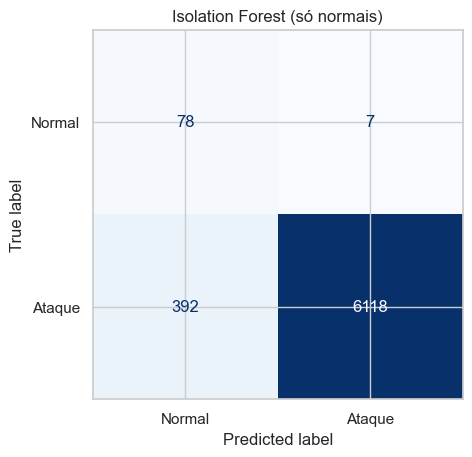

In [28]:
PERCENTIL_LIMIAR = 95     # tolera ~5% de falsos alarmes sobre o tráfego normal de treino

X_train_normal = X_train[y_train_bin == 0]

iso = IsolationForest(n_estimators=300, random_state=SEED, n_jobs=-1)
iso.fit(X_train_normal)

# score_samples: quanto MENOR, mais anômalo -> invertemos o sinal (maior = mais anômalo)
score_treino_normal = -iso.score_samples(X_train_normal)
limiar = np.percentile(score_treino_normal, PERCENTIL_LIMIAR)

score_teste = -iso.score_samples(X_test)
y_pred_iso = (score_teste > limiar).astype(int)      # 1 = anomalia = ataque

avaliar_binario("Isolation Forest (só normais)", y_test_bin, y_pred_iso, score_teste)

### 4.6 Resultado agregado

In [29]:
print("CLASSIFICAÇÃO BINÁRIA (positivo = ataque)")
display(pd.DataFrame(res_bin).set_index("Modelo").round(4))

print(f"\nCLASSIFICAÇÃO MULTICLASSE (alvo = '{ALVO_MULTICLASSE}')")
display(pd.DataFrame(res_multi).set_index("Modelo").round(4))

CLASSIFICAÇÃO BINÁRIA (positivo = ataque)


,Precision (ataque),Recall (ataque),F1 (ataque),Recall (normal),F1 macro,PR-AUC (ataque)
Modelo,,,,,,
Random Forest (binário),1.0000,0.9998,0.9999,1.0000,0.9970,1.0000
XGBoost (binário),1.0000,0.9962,0.9981,1.0000,0.9349,1.0000
Isolation Forest (só normais),0.9989,0.9398,0.9684,0.9176,0.6248,0.9997



CLASSIFICAÇÃO MULTICLASSE (alvo = 'category')


,Precision macro,Recall macro,F1 macro,Recall (normal),F1 (normal)
Modelo,,,,,
Random Forest (multiclasse),0.9941,0.9808,0.9872,0.9882,0.9882
XGBoost (multiclasse),0.9928,0.9795,0.9859,0.9765,0.9765


---
## Refinamento da avaliação: conflitos, validação cruzada, ataques inéditos e ablação

Os resultados da seção 4 (~99,9%) vêm de **um único** split aleatório e de um teste com apenas 85 normais e 15 *theft*. Esta seção testa o quanto esses números merecem confiança, respondendo quatro perguntas:

| Seção | Pergunta |
| :--- | :--- |
| 5.1 | Quais classes disputam os mesmos vetores de features (conflitos de rótulo)? |
| 5.2 | Os resultados são estáveis ou dependem da sorte do split? (validação cruzada) |
| 5.3 | O modelo detecta uma **família de ataque que nunca viu**? (*leave-one-attack-out*) |
| 5.4 | O desempenho depende de poucas features, possíveis "atalhos" do testbed? (ablação) |

In [ ]:
# Imports adicionais desta seção
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

fmt = lambda n: f"{n:,}".replace(",", ".")

### 5.1 Conflitos de rótulo: quem disputa o mesmo vetor de features?

No Passo 1.2 vimos linhas com **features idênticas e rótulos diferentes**. Nenhum modelo consegue acertar todas, pois a mesma entrada leva a duas respostas. Aqui descobrimos *quais* classes colidem:

1. `duplicated(subset=FEATURES, keep=False)` marca todas as linhas que compartilham o vetor de features com outra.
2. `groupby(FEATURES).ngroup()` dá um `vetor_id` a cada vetor repetido.
3. Para cada `vetor_id`, listamos as classes envolvidas (ex.: `ddos_tcp vs dos_tcp`) e contamos.

In [31]:
mask_conf = df_clean.duplicated(subset=FEATURES, keep=False)
df_conf = df_clean.loc[mask_conf].copy()
print(f"Linhas em conflito: {fmt(len(df_conf))} ({len(df_conf) / len(df_clean):.3%} do dataset limpo) "
      f"| confere com o Passo 1.2: {len(df_conf) == n_conflitos}")

if len(df_conf) > 0:
    # um id por vetor de features repetido
    df_conf["vetor_id"] = df_conf.groupby(FEATURES, sort=False).ngroup()

    # para cada vetor, quais classes disputam? (ex.: "ddos_tcp vs dos_tcp")
    disputa = df_conf.groupby("vetor_id")["classe"].agg(lambda s: " vs ".join(sorted(s.unique())))
    disputa_por_linha = df_conf["vetor_id"].map(disputa)

    resumo = pd.DataFrame({
        "vetores_distintos": disputa.value_counts(),
        "linhas": disputa_por_linha.value_counts(),
    }).sort_values("linhas", ascending=False)
    print("\nQuais classes disputam o mesmo vetor de features:")
    display(resumo)

    so_flood = lambda c: all(x.split("_")[0] in ("ddos", "dos") for x in c.split(" vs "))
    n_flood  = disputa_por_linha.map(so_flood).sum()
    n_normal = disputa_por_linha.str.contains("normal").sum()
    print(f"Conflitos apenas entre DDoS e DoS : {fmt(n_flood)} linhas ({n_flood / len(df_conf):.1%})")
    print(f"Conflitos que envolvem 'normal'   : {fmt(n_normal)} linhas ({n_normal / len(df_conf):.1%})")

n_conf_bal = df_bal.duplicated(subset=FEATURES, keep=False).sum()
print(f"\nNo dataset balanceado (df_bal), restam {fmt(n_conf_bal)} linhas com features repetidas.")

Linhas em conflito: 5.754 (0.348% do dataset limpo) | confere com o Passo 1.2: True

Quais classes disputam o mesmo vetor de features:


,vetores_distintos,linhas
reconnaissance_os_fingerprint vs reconnaissance_service_scan,2481,4962
ddos_tcp vs dos_tcp,363,726
ddos_tcp vs reconnaissance_os_fingerprint,22,44
ddos_tcp vs reconnaissance_service_scan,7,14
ddos_tcp vs dos_tcp vs reconnaissance_os_fingerprint vs reconnaissance_service_scan,1,4
normal vs reconnaissance_service_scan,2,4


Conflitos apenas entre DDoS e DoS : 726 linhas (12.6%)
Conflitos que envolvem 'normal'   : 4 linhas (0.1%)

No dataset balanceado (df_bal), restam 912 linhas com features repetidas.


**E se DoS e DDoS forem fundidos?** A diferença entre os dois é *quantas máquinas atacam*, informação que um fluxo individual (sem IPs) não carrega. Criamos a coluna `familia`, que une os dois em `flood`, e medimos quantos conflitos desaparecem. Mais adiante (5.2) o multiclasse é avaliado nos dois alvos, `category` e `familia`, para comparar.

> Depois da fusão sobram algumas linhas duplicadas com o *mesmo* rótulo. Não são conflitos, e são poucas.

In [32]:
MAPA_FAMILIA = {"ddos": "flood", "dos": "flood"}
agrupar = lambda c: MAPA_FAMILIA.get(c, c)

df_clean["familia"] = df_clean["category"].map(agrupar)
df_bal["familia"]   = df_bal["category"].map(agrupar)
if "familia" not in COLUNAS_ROTULO:
    COLUNAS_ROTULO.append("familia")        # garante que 'familia' nunca entre como feature

if len(df_conf) > 0:
    df_conf["familia"] = df_conf["category"].map(agrupar)
    ainda_conflita = df_conf.groupby("vetor_id")["familia"].transform("nunique") > 1
    print(f"Linhas em conflito com 5 classes (category) : {fmt(len(df_conf))}")
    print(f"Linhas em conflito após fundir DDoS+DoS      : {fmt(ainda_conflita.sum())}")

print("\nAlvo 'familia' no dataset balanceado:")
print(df_bal["familia"].value_counts())

Linhas em conflito com 5 classes (category) : 5.754
Linhas em conflito após fundir DDoS+DoS      : 66

Alvo 'familia' no dataset balanceado:
familia
flood             22474
reconnaissance    10000
normal              423
theft                75
Name: count, dtype: int64


### 5.2 Validação cruzada estratificada (5 dobras)

**Ideia:** em vez de um único split 80/20, dividimos o dataset em 5 partes. Em cada rodada, 4 partes treinam e 1 testa, até que *todas* as amostras tenham sido testadas uma vez. Em vez de um número, obtemos **média ± desvio-padrão**:

* desvio pequeno → o resultado é estável;
* desvio grande (típico em *Recall normal* e *Recall theft*, que têm poucas amostras por dobra) → o número único da seção 4 era em parte sorte.

`StratifiedKFold` com `stratify = classe` mantém a proporção de cada classe em todas as dobras (essencial para `theft` e `data_exfiltration`, que são raras).

#### Funções auxiliares (reutilizadas em 5.3 e 5.4)

* `prever_binario(modelo, ...)` e `prever_multiclasse(modelo, ...)` treinam um modelo do zero com os mesmos hiperparâmetros da seção 4 e devolvem as previsões.
* `xgb_sem_peso` é o XGBoost **sem** `scale_pos_weight`, para testar a hipótese de que o peso empurrou ataques para "normal" (os ~25 ataques perdidos da seção 4).
* `metricas_binarias` inclui duas métricas independentes de limiar: **ROC-AUC** e **PR-AUC com `normal` como classe positiva**. A PR-AUC do *ataque* usada antes tinha baseline ≈ 0,987, então quase nada informava.

In [33]:
def prever_binario(modelo, Xtr, ytr, Xte, n_arvores=200):
    """Treina `modelo` ('rf' | 'xgb' | 'xgb_sem_peso' | 'iso') e devolve (pred, score) em Xte.
    pred: 0 = normal, 1 = ataque.  score: quanto MAIOR, mais provável ser ataque."""
    ytr = np.asarray(ytr)

    if modelo == "rf":
        m = RandomForestClassifier(n_estimators=n_arvores, class_weight="balanced",
                                   n_jobs=-1, random_state=SEED).fit(Xtr, ytr)
        return m.predict(Xte), m.predict_proba(Xte)[:, 1]

    if modelo in ("xgb", "xgb_sem_peso"):
        spw = (ytr == 0).sum() / (ytr == 1).sum() if modelo == "xgb" else 1.0
        m = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, scale_pos_weight=spw,
                          tree_method="hist", eval_metric="logloss", n_jobs=-1, random_state=SEED).fit(Xtr, ytr)
        return m.predict(Xte), m.predict_proba(Xte)[:, 1]

    if modelo == "iso":                                   # só enxerga tráfego normal no treino
        Xn = Xtr[ytr == 0]
        m = IsolationForest(n_estimators=300, random_state=SEED, n_jobs=-1).fit(Xn)
        limiar = np.percentile(-m.score_samples(Xn), PERCENTIL_LIMIAR)
        score = -m.score_samples(Xte)
        return (score > limiar).astype(int), score

    raise ValueError(modelo)


def prever_multiclasse(modelo, Xtr, ytr, Xte):
    """Treina 'rf' ou 'xgb' para um alvo com várias classes (texto) e devolve as previsões em Xte."""
    ytr = np.asarray(ytr)
    if modelo == "rf":
        m = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                   n_jobs=-1, random_state=SEED).fit(Xtr, ytr)
        return m.predict(Xte)
    if modelo == "xgb":
        le = LabelEncoder().fit(ytr)
        y_enc = le.transform(ytr)
        m = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, tree_method="hist",
                          eval_metric="mlogloss", n_jobs=-1, random_state=SEED)
        m.fit(Xtr, y_enc, sample_weight=compute_sample_weight("balanced", y_enc))
        return le.inverse_transform(m.predict(Xte))
    raise ValueError(modelo)


def metricas_binarias(y_true, y_pred, score):
    y_true, y_pred, score = np.asarray(y_true), np.asarray(y_pred), np.asarray(score)
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    return {
        "Precision (ataque)": p[1], "Recall (ataque)": r[1], "F1 (ataque)": f[1],
        "Precision (normal)": p[0], "Recall (normal)": r[0], "F1 macro": f.mean(),
        "ROC-AUC": roc_auc_score(y_true, score),
        "PR-AUC (normal)": average_precision_score(1 - y_true, -score),   # normal como classe positiva
        "FN (ataques perdidos)": int(((y_true == 1) & (y_pred == 0)).sum()),
        "FP (alarmes falsos)":   int(((y_true == 0) & (y_pred == 1)).sum()),
    }


def metricas_multiclasse(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    labels = sorted(set(y_true))
    _, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)
    rec = dict(zip(labels, r))
    return {"F1 macro": f.mean(), "Recall macro": r.mean(),
            "Recall (normal)": rec["normal"], "Recall (theft)": rec["theft"]}


def resumir(df, chaves):
    """média ± desvio-padrão por grupo (ignora a coluna 'fold')."""
    g = df.drop(columns="fold").groupby(chaves)
    return g.mean().round(4).astype(str) + " ± " + g.std().round(4).astype(str)


NOMES_BIN = {"rf": "Random Forest", "xgb": "XGBoost", "xgb_sem_peso": "XGBoost (sem peso)", "iso": "Isolation Forest"}

In [34]:
N_SPLITS = 5

X_all       = df_bal[FEATURES]
y_all_bin   = df_bal["attack"].to_numpy()
estrato     = df_bal["classe"].to_numpy()
ALVOS_MULTI = {"category": df_bal["category"].to_numpy(),      # 5 classes (ddos e dos separados)
               "familia":  df_bal["familia"].to_numpy()}       # 4 classes (ddos+dos = flood)

skf   = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
FOLDS = list(skf.split(X_all, estrato))        # guardamos: 5.4 reutiliza exatamente as mesmas dobras

cv_bin, cv_multi = [], []
for k, (i_tr, i_te) in enumerate(FOLDS, start=1):
    Xtr, Xte = X_all.iloc[i_tr], X_all.iloc[i_te]

    for m in NOMES_BIN:
        pred, score = prever_binario(m, Xtr, y_all_bin[i_tr], Xte)
        cv_bin.append({"fold": k, "Modelo": NOMES_BIN[m], **metricas_binarias(y_all_bin[i_te], pred, score)})

    for nome_alvo, y_alvo in ALVOS_MULTI.items():
        for m in ("rf", "xgb"):
            pred = prever_multiclasse(m, Xtr, y_alvo[i_tr], Xte)
            cv_multi.append({"fold": k, "Alvo": nome_alvo, "Modelo": NOMES_BIN[m],
                             **metricas_multiclasse(y_alvo[i_te], pred)})
    print(f"Dobra {k}/{N_SPLITS} concluída")

df_cv_bin, df_cv_multi = pd.DataFrame(cv_bin), pd.DataFrame(cv_multi)

Dobra 1/5 concluída
Dobra 2/5 concluída
Dobra 3/5 concluída
Dobra 4/5 concluída
Dobra 5/5 concluída


In [35]:
print(f"VALIDAÇÃO CRUZADA ({N_SPLITS} dobras): CLASSIFICAÇÃO BINÁRIA (positivo = ataque)")
print(f"FN/FP são médias por dobra (~{fmt(len(FOLDS[0][1]))} amostras de teste e ~{int((y_all_bin == 0).sum() / N_SPLITS)} normais por dobra)\n")
display(resumir(df_cv_bin, "Modelo"))

print("\nVALIDAÇÃO CRUZADA: MULTICLASSE")
display(resumir(df_cv_multi, ["Alvo", "Modelo"]))

VALIDAÇÃO CRUZADA (5 dobras): CLASSIFICAÇÃO BINÁRIA (positivo = ataque)
FN/FP são médias por dobra (~6.595 amostras de teste e ~84 normais por dobra)



,Precision (ataque),Recall (ataque),F1 (ataque),Precision (normal),Recall (normal),F1 macro,ROC-AUC,PR-AUC (normal),FN (ataques perdidos),FP (alarmes falsos)
Modelo,,,,,,,,,,
Isolation Forest,0.999 ± 0.0003,0.8822 ± 0.1047,0.9342 ± 0.064,0.1251 ± 0.0498,0.9338 ± 0.0232,0.5758 ± 0.0729,0.9735 ± 0.0143,0.7705 ± 0.0486,766.6 ± 681.8939,5.6 ± 1.9494
Random Forest,0.9999 ± 0.0001,0.9995 ± 0.0005,0.9997 ± 0.0002,0.9642 ± 0.0316,0.9905 ± 0.01,0.9883 ± 0.0085,1.0 ± 0.0,0.999 ± 0.0007,3.2 ± 2.9496,0.8 ± 0.8367
XGBoost,1.0 ± 0.0001,0.9959 ± 0.0008,0.998 ± 0.0004,0.7633 ± 0.0354,0.9976 ± 0.0053,0.9312 ± 0.011,0.9998 ± 0.0001,0.9838 ± 0.0082,26.4 ± 5.4129,0.2 ± 0.4472
XGBoost (sem peso),0.9998 ± 0.0002,0.9998 ± 0.0005,0.9998 ± 0.0003,0.9821 ± 0.0339,0.9834 ± 0.0159,0.9911 ± 0.0102,1.0 ± 0.0,0.9985 ± 0.0017,1.6 ± 3.0496,1.4 ± 1.3416



VALIDAÇÃO CRUZADA: MULTICLASSE


F1 macro     Recall macro  Recall (normal)   Recall (theft)
Alvo     Modelo                                                                           
category Random Forest  0.9791 ± 0.0133   0.977 ± 0.0206  0.9929 ± 0.0106  0.9067 ± 0.1011
         XGBoost        0.9795 ± 0.0118  0.9799 ± 0.0155  0.9929 ± 0.0106     0.92 ± 0.073
familia  Random Forest  0.9744 ± 0.0138   0.9675 ± 0.025  0.9929 ± 0.0106    0.88 ± 0.0989
         XGBoost         0.9715 ± 0.016  0.9737 ± 0.0188    0.9905 ± 0.01   0.9067 ± 0.076

### 5.3 *Leave-one-attack-out*: detectar uma família de ataque **inédita**

Na seção 4, o treino continha exemplos de *todas* as famílias de ataque. Um IDS real enfrenta ataques que nunca viu. Aqui simulamos isso:

1. Escolhemos uma família (`ddos`, `dos`, `reconnaissance` ou `theft`) e **removemos todos os seus exemplos do treino**.
2. Treinamos com as outras famílias e 80% dos normais.
3. Testamos nos ataques da família retida e nos 20% restantes dos normais (para medir alarmes falsos).

**Como ler:**

* **Recall (ataque):** fração da família inédita que foi detectada. Aqui *é* o resultado principal. A Precision não é informativa, pois a proporção ataque/normal do teste é arbitrária.
* **Recall (normal):** fração do tráfego legítimo que não gerou alarme (1 − taxa de falsos alarmes).
* **ROC-AUC:** o quanto o *score* do modelo separa a família inédita dos normais, **sem depender do limiar**.

> **Cuidado ao interpretar `ddos` e `dos`:** como os dois têm comportamento quase igual, reter um deles deixa o "gêmeo" no treino, então a "novidade" é só parcial. `reconnaissance` (varreduras) é a família que mais difere dos demais. `theft` tem poucos exemplos (~75), então seu resultado é ruidoso.
>
> O Isolation Forest treina só com normais, então seu modelo é o mesmo em todas as famílias; só muda o que ele é testado contra.

In [36]:
FAMILIAS = ["ddos", "dos", "reconnaissance", "theft"]
cat_all  = df_bal["category"].to_numpy()

# Os normais são divididos uma única vez (80% treino / 20% teste) e reaproveitados em todas as famílias
idx_normais = np.where(y_all_bin == 0)[0]
normais_tr, normais_te = train_test_split(idx_normais, test_size=0.2, random_state=SEED)

SPLITS_LOAO = {}
for fam in FAMILIAS:
    ataques_fam    = np.where(cat_all == fam)[0]                              # vão SÓ para o teste
    ataques_outros = np.where((cat_all != fam) & (y_all_bin == 1))[0]         # treino
    SPLITS_LOAO[fam] = (np.concatenate([normais_tr, ataques_outros]),
                        np.concatenate([normais_te, ataques_fam]))
    print(f"{fam:15s} -> teste: {len(ataques_fam):6d} ataques inéditos + {len(normais_te)} normais"
          f" | treino: {len(ataques_outros):6d} ataques (outras famílias) + {len(normais_tr)} normais")

ddos            -> teste:  10989 ataques inéditos + 85 normais | treino:  21560 ataques (outras famílias) + 338 normais
dos             -> teste:  11485 ataques inéditos + 85 normais | treino:  21064 ataques (outras famílias) + 338 normais
reconnaissance  -> teste:  10000 ataques inéditos + 85 normais | treino:  22549 ataques (outras famílias) + 338 normais
theft           -> teste:     75 ataques inéditos + 85 normais | treino:  32474 ataques (outras famílias) + 338 normais


In [37]:
res_loao = []
for fam, (i_tr, i_te) in SPLITS_LOAO.items():
    Xtr, Xte = X_all.iloc[i_tr], X_all.iloc[i_te]
    for m in NOMES_BIN:
        pred, score = prever_binario(m, Xtr, y_all_bin[i_tr], Xte)
        res_loao.append({"Família retida": fam, "Modelo": NOMES_BIN[m],
                         **metricas_binarias(y_all_bin[i_te], pred, score)})
    print(f"Família '{fam}' concluída")

df_loao = pd.DataFrame(res_loao)

for coluna, titulo in [("Recall (ataque)", "RECALL na família INÉDITA (quanto foi detectado)"),
                       ("ROC-AUC",         "ROC-AUC (separação ataque inédito vs normal, sem limiar)"),
                       ("Recall (normal)", "RECALL dos normais (1 = nenhum alarme falso)")]:
    print(f"\n{titulo}")
    display(df_loao.pivot(index="Família retida", columns="Modelo", values=coluna).round(4))

Família 'ddos' concluída
Família 'dos' concluída
Família 'reconnaissance' concluída
Família 'theft' concluída

RECALL na família INÉDITA (quanto foi detectado)


Modelo,Isolation Forest,Random Forest,XGBoost,XGBoost (sem peso)
Família retida,,,,
ddos,0.9990,1.0000,0.9999,1.0000
dos,0.9595,0.9910,0.9808,0.9885
reconnaissance,0.8418,0.8770,0.9303,0.9624
theft,0.3067,0.9333,0.6533,0.9733



ROC-AUC (separação ataque inédito vs normal, sem limiar)


Modelo,Isolation Forest,Random Forest,XGBoost,XGBoost (sem peso)
Família retida,,,,
ddos,0.9956,1.0000,1.0000,1.0000
dos,0.9775,0.9998,0.9982,0.9993
reconnaissance,0.9211,0.9956,0.9927,0.9947
theft,0.8598,0.9956,0.9934,0.9986



RECALL dos normais (1 = nenhum alarme falso)


Modelo,Isolation Forest,Random Forest,XGBoost,XGBoost (sem peso)
Família retida,,,,
ddos,0.8824,0.9765,1.0,0.9765
dos,0.8824,0.9882,1.0,1.0000
reconnaissance,0.8824,0.9765,1.0,0.9647
theft,0.8824,0.9765,1.0,0.9882


### 5.4 Ablação de features e importância por permutação

**Pergunta:** o desempenho vem de comportamento "geral" de ataque ou de poucas features que talvez sejam atalhos do testbed (como os contadores de conexão, `N_IN_Conn_P_*`, que saturam em 100 sob inundação)?

**Ablação por grupo:** retiramos um grupo de features por vez, retreinamos o Random Forest e vemos o quanto o desempenho cai. Quanto maior a queda, mais o modelo dependia do grupo. Há também um teste inverso, `somente contadores`: se só eles já bastam, são um atalho.

Cada configuração é avaliada de dois jeitos:

* **CV:** as mesmas 5 dobras da 5.2 (ataques de todas as famílias vistos no treino).
* **Inédito:** os 4 cenários *leave-one-attack-out* da 5.3 (o que mais importa para generalização).

Grupos de features:

| Grupo | Colunas |
| :--- | :--- |
| contadores de conexão | `N_IN_Conn_P_SrcIP`, `N_IN_Conn_P_DstIP` |
| duração/estatísticas | `stddev`, `min`, `mean`, `max` |
| taxas | `srate`, `drate` |
| state_number | `state_number` |
| protocolo | `proto_*` (one-hot) |

Para economizar tempo, a ablação usa Random Forest com `N_ARVORES_ABLACAO` árvores (mude para 200 para ficar idêntico à seção 4).

In [38]:
N_ARVORES_ABLACAO = 100

GRUPOS = {
    "contadores de conexão": ["N_IN_Conn_P_SrcIP", "N_IN_Conn_P_DstIP"],
    "duração/estatísticas":  ["stddev", "min", "mean", "max"],
    "taxas":                 ["srate", "drate"],
    "state_number":          ["state_number"],
    "protocolo":             [c for c in FEATURES if c.startswith("proto_")],
}
assert sorted(sum(GRUPOS.values(), [])) == sorted(FEATURES), "algum grupo está faltando/sobrando"

CONFIGS = {"completo (baseline)": FEATURES}
for nome, cols in GRUPOS.items():
    CONFIGS[f"sem {nome}"] = [c for c in FEATURES if c not in cols]
CONFIGS["SOMENTE contadores de conexão"] = GRUPOS["contadores de conexão"]


def avaliar_config(cols):
    cv = []
    for i_tr, i_te in FOLDS:
        pred, score = prever_binario("rf", X_all.iloc[i_tr][cols], y_all_bin[i_tr],
                                     X_all.iloc[i_te][cols], n_arvores=N_ARVORES_ABLACAO)
        cv.append(metricas_binarias(y_all_bin[i_te], pred, score))
    cv = pd.DataFrame(cv).mean()

    linha = {"F1 macro (CV)": cv["F1 macro"], "Recall ataque (CV)": cv["Recall (ataque)"],
             "Recall normal (CV)": cv["Recall (normal)"]}
    inedito = []
    for fam, (i_tr, i_te) in SPLITS_LOAO.items():
        pred, score = prever_binario("rf", X_all.iloc[i_tr][cols], y_all_bin[i_tr],
                                     X_all.iloc[i_te][cols], n_arvores=N_ARVORES_ABLACAO)
        rec = metricas_binarias(y_all_bin[i_te], pred, score)["Recall (ataque)"]
        linha[f"Recall inédito: {fam}"] = rec
        inedito.append(rec)
    linha["Recall inédito (média)"] = np.mean(inedito)
    return linha


linhas_ablacao = {}
for nome, cols in CONFIGS.items():
    linhas_ablacao[nome] = avaliar_config(cols)
    print(f"{nome:32s} ({len(cols):2d} features) concluído")

df_ablacao = pd.DataFrame(linhas_ablacao).T
print("\nABLAÇÃO (Random Forest binário). Compare cada linha com 'completo (baseline)':")
display(df_ablacao.round(4))

completo (baseline)              (14 features) concluído
sem contadores de conexão        (12 features) concluído
sem duração/estatísticas         (10 features) concluído
sem taxas                        (12 features) concluído
sem state_number                 (13 features) concluído
sem protocolo                    ( 9 features) concluído
SOMENTE contadores de conexão    ( 2 features) concluído

ABLAÇÃO (Random Forest binário). Compare cada linha com 'completo (baseline)':


,F1 macro (CV),Recall ataque (CV),Recall normal (CV),Recall inédito: ddos,Recall inédito: dos,Recall inédito: reconnaissance,Recall inédito: theft,Recall inédito (média)
completo (baseline),0.9888,0.9996,0.9881,1.0000,0.9913,0.8754,0.9333,0.9500
sem contadores de conexão,0.9646,0.9986,0.9621,0.9997,0.9995,0.8462,0.9467,0.9480
sem duração/estatísticas,0.9832,0.9992,0.9905,1.0000,0.9859,0.9624,0.8667,0.9537
sem taxas,0.9889,0.9995,0.9929,1.0000,0.9895,0.8891,0.9733,0.9630
sem state_number,0.9883,0.9995,0.9929,1.0000,0.9923,0.8797,0.9733,0.9613
sem protocolo,0.9864,0.9994,0.9881,1.0000,0.9915,0.9628,0.8800,0.9586
SOMENTE contadores de conexão,0.9101,0.9947,0.9834,0.9997,0.9827,0.9580,0.9467,0.9718


**Importância por permutação:** no conjunto de teste da seção 4, embaralhamos **uma feature por vez** e medimos o quanto o F1 macro cai. Se embaralhar a feature não muda nada, o modelo não dependia dela.

> **Limitação:** com features correlacionadas (ex.: `mean` e `max`, r = 0,89), a importância se **divide** entre elas e cada uma parece menos importante do que o grupo é. Por isso a ablação por *grupo* acima é a leitura mais confiável; a permutação serve como visão complementar, por feature.

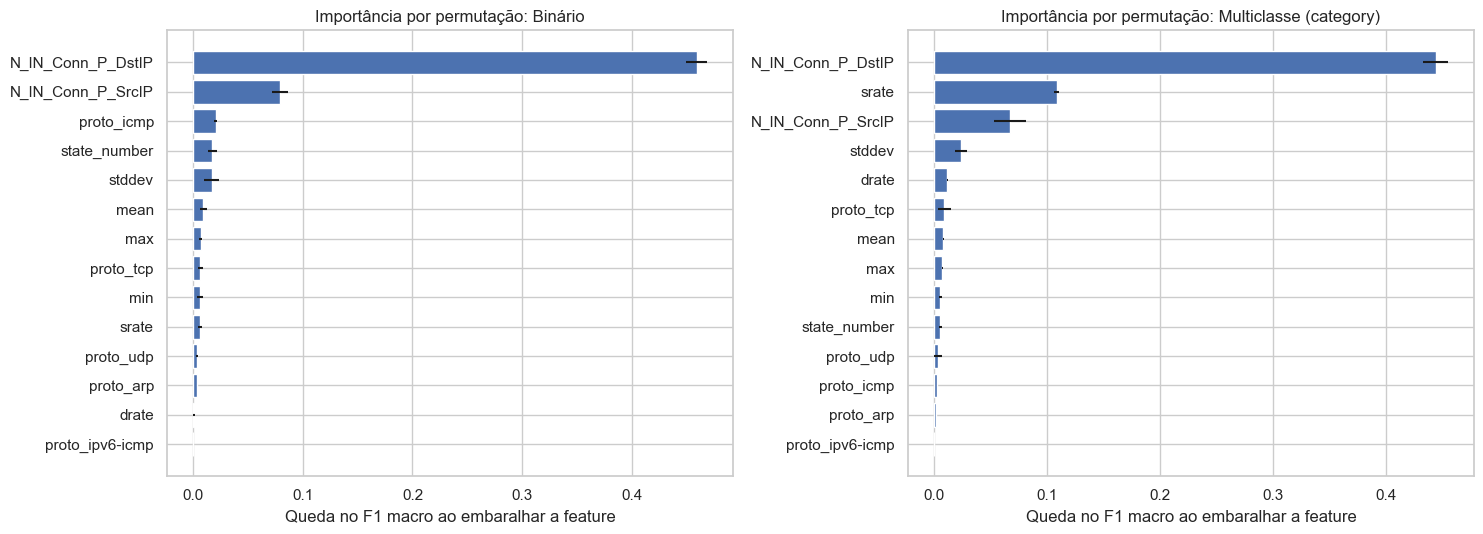

In [39]:
imp_bin   = permutation_importance(rf_bin,   X_test, y_test_bin,   scoring="f1_macro",
                                   n_repeats=10, random_state=SEED, n_jobs=-1)
imp_multi = permutation_importance(rf_multi, X_test, y_test_multi, scoring="f1_macro",
                                   n_repeats=10, random_state=SEED, n_jobs=-1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, imp, titulo in zip(axes, (imp_bin, imp_multi), ("Binário", f"Multiclasse ({ALVO_MULTICLASSE})")):
    ordem = np.argsort(imp.importances_mean)
    ax.barh(np.array(FEATURES)[ordem], imp.importances_mean[ordem], xerr=imp.importances_std[ordem])
    ax.set_title(f"Importância por permutação: {titulo}")
    ax.set_xlabel("Queda no F1 macro ao embaralhar a feature")
plt.tight_layout()
plt.show()

### 5.5 Guia de interpretação

| O que você observar | O que provavelmente significa |
| :--- | :--- |
| 5.2: desvios pequenos e médias ≈ seção 4 | O resultado da seção 4 era estável |
| 5.2: desvio grande em *Recall (normal)* / *Recall (theft)* | Poucas amostras dessas classes por dobra; trate esses números como ruído |
| 5.2: `familia` com F1 macro maior que `category` | A confusão DDoS↔DoS é limite dos dados (mesmas features, rótulos diferentes), não do modelo |
| 5.2: `XGBoost (sem peso)` perde menos ataques (FN) que `XGBoost` | O `scale_pos_weight` deslocava a fronteira para "normal" |
| 5.3: Recall alto em todas as famílias | As features capturam comportamento de ataque que generaliza (dentro deste testbed) |
| 5.3: Recall baixo em uma família, ex.: `reconnaissance` | Os modelos supervisionados memorizam assinaturas das famílias vistas |
| 5.3: Isolation Forest com ROC-AUC alto mas Recall baixo | O *score* separa bem, e o problema é só o limiar (percentil), que dá para ajustar |
| 5.4: "sem contadores" derruba o *Recall inédito* | Os contadores são um atalho de que a generalização depende |
| 5.4: "SOMENTE contadores" quase tão bom quanto o completo | Duas features resolvem o problema: sinal de alerta de atalho do testbed |
| 5.4: nenhuma remoção muda muito | Informação redundante entre grupos; o sinal está espalhado |

Lembrete: em tudo isso o Bot-IoT continua sendo **um único testbed**. Mesmo um resultado ótimo aqui não prova generalização para um ESP32 real.